In [37]:
#a2
def my_label_encode(column):
    unique_vals = sorted(column.unique())
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    encoded_column = column.map(mapping)
    return encoded_column, mapping

def my_one_hot_encode(column):
    encoded_df = pd.get_dummies(column, prefix=column.name).astype(int)
    return encoded_df

def my_apply_label_encoding(data, columns):
    data = data.copy()
    mappings = {}
    for col in columns:
        encoded_col, mapping = my_label_encode(data[col])
        data[col + '_encoded'] = encoded_col
        mappings[col] = mapping
    return data, mappings

def my_apply_one_hot_encoding(data, columns):
    data = data.copy()
    for col in columns:
        ohe = my_one_hot_encode(data[col])
        data = pd.concat([data, ohe], axis=1)
        data = data.drop(columns=[col])
    return data

# TEST
test_col = pd.Series(["A", "B", "A", "C"], name="test")
test_encoded, test_map = my_label_encode(test_col)
print("Label encoded:", test_encoded.tolist(), "| mapping:", test_map)
print("One-hot encoded:")
print(my_one_hot_encode(test_col))

Label encoded: [0, 1, 0, 2] | mapping: {'A': 0, 'B': 1, 'C': 2}
One-hot encoded:
   test_A  test_B  test_C
0       1       0       0
1       0       1       0
2       1       0       0
3       0       0       1


In [38]:
#a3
cat_cols = ["Education", "Marital_Status"]

original_shape = df.shape
label_df, mappings = my_apply_label_encoding(df, cat_cols)
onehot_df = my_apply_one_hot_encoding(df, cat_cols)

print("Original shape:", original_shape)
print("Mappings:", mappings)
print(label_df[["Education", "Education_encoded", "Marital_Status", "Marital_Status_encoded"]].head())
print("Label-encoded shape:", label_df.shape)
print("One-hot encoded shape:", onehot_df.shape)
onehot_df.head()

Original shape: (2240, 29)
Mappings: {'Education': {'2n Cycle': 0, 'Basic': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}, 'Marital_Status': {'Absurd': 0, 'Alone': 1, 'Divorced': 2, 'Married': 3, 'Single': 4, 'Together': 5, 'Widow': 6, 'YOLO': 7}}
    Education  Education_encoded Marital_Status  Marital_Status_encoded
0  Graduation                  2         Single                       4
1  Graduation                  2         Single                       4
2  Graduation                  2       Together                       5
3  Graduation                  2       Together                       5
4         PhD                  4        Married                       3
Label-encoded shape: (2240, 31)
One-hot encoded shape: (2240, 40)


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,2012-04-09 00:00:00,58,635,88,546,...,0,0,0,0,0,0,1,0,0,0
1,2174,1954,46344.0,1,1,2014-08-03 00:00:00,38,11,1,6,...,0,0,0,0,0,0,1,0,0,0
2,4141,1965,71613.0,0,0,21-08-2013,26,426,49,127,...,0,0,0,0,0,0,0,1,0,0
3,6182,1984,26646.0,1,0,2014-10-02 00:00:00,26,11,4,20,...,0,0,0,0,0,0,0,1,0,0
4,5324,1981,58293.0,1,0,19-01-2014,94,173,43,118,...,0,1,0,0,0,1,0,0,0,0


In [39]:
#a4
def minkowski_distance(vector1, vector2, p):
    vector1 = np.array(vector1, dtype=float)
    vector2 = np.array(vector2, dtype=float)
    distance_value = np.sum(np.abs(vector1 - vector2) ** p) ** (1 / p)
    return distance_value
# p=1 -> Manhattan distance, p=2 -> Euclidean distance

# quick test
print("Test distance (p=1):", minkowski_distance([1, 2], [4, 6], 1))
print("Test distance (p=2):", minkowski_distance([1, 2], [4, 6], 2))

Test distance (p=1): 7.0
Test distance (p=2): 5.0


vector A: [np.float64(58138.0) np.int64(58) np.int64(635) np.int64(88) np.int64(546)
 np.int64(172) np.int64(88) np.int64(88) np.int64(3) np.int64(8)
 np.int64(10) np.int64(4) np.int64(7)]
vector B: [np.float64(46344.0) np.int64(38) np.int64(11) np.int64(1) np.int64(6)
 np.int64(2) np.int64(1) np.int64(6) np.int64(2) np.int64(1) np.int64(1)
 np.int64(2) np.int64(5)]
Distances p=1 to 10: [np.float64(13425.0), np.float64(11825.003720929648), np.float64(11794.975787143821), np.float64(11794.036213715499), np.float64(11794.001454169289), np.float64(11794.000061245157), np.float64(11794.00000266629), np.float64(11794.000000118998), np.float64(11794.00000000541), np.float64(11794.000000000256)]


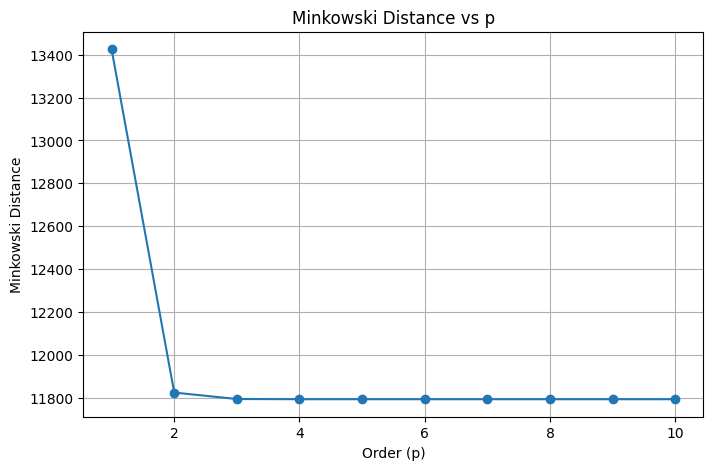

In [40]:
#a5
numeric_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases', 'NumWebVisitsMonth']

vector_A = df.loc[0, numeric_cols].values
vector_B = df.loc[1, numeric_cols].values
print("vector A:", vector_A)
print("vector B:", vector_B)

p_values = list(range(1, 11))
own_distances = [minkowski_distance(vector_A, vector_B, p) for p in p_values]

print("Distances p=1 to 10:", own_distances)

plt.figure(figsize=(8, 5))
plt.plot(p_values, own_distances, marker='o')
plt.xlabel('Order (p)')
plt.ylabel('Minkowski Distance')
plt.title('Minkowski Distance vs p')
plt.grid(True)
plt.show()

In [41]:
#a6
scipy_distances = [distance.minkowski(vector_A, vector_B, p) for p in p_values]

comparison_df = pd.DataFrame({
    'p': p_values,
    'Own Function': own_distances,
    'Scipy Function': scipy_distances
})
print(comparison_df)

    p  Own Function  Scipy Function
0   1  13425.000000    13425.000000
1   2  11825.003721    11825.003721
2   3  11794.975787    11794.975787
3   4  11794.036214    11794.036214
4   5  11794.001454    11794.001454
5   6  11794.000061    11794.000061
6   7  11794.000003    11794.000000
7   8  11794.000000    11794.000000
8   9  11794.000000    11794.000000
9  10  11794.000000    11794.000000


In [42]:
#a7
def dot_product(vector1, vector2):
    vector1 = np.array(vector1, dtype=float)
    vector2 = np.array(vector2, dtype=float)
    return np.sum(vector1 * vector2)

def euclidean_norm(vector):
    vector = np.array(vector, dtype=float)
    return np.sqrt(np.sum(vector ** 2))

own_dot = dot_product(vector_A, vector_B)
own_norm_A = euclidean_norm(vector_A)
numpy_dot = np.dot(vector_A.astype(float), vector_B.astype(float))
numpy_norm_A = np.linalg.norm(vector_A.astype(float))

print("Own dot product:", own_dot, " | Numpy dot product:", numpy_dot)
print("Own norm of A:", own_norm_A, " | Numpy norm of A:", numpy_norm_A)

Own dot product: 2694361052.0  | Numpy dot product: 2694361052.0
Own norm of A: 58144.51653423563  | Numpy norm of A: 58144.51653423563


In [43]:
#a8
def calculate_mean(data_matrix):
    n_samples = data_matrix.shape[0]
    return np.sum(data_matrix, axis=0) / n_samples

def calculate_variance(data_matrix):
    n_samples = data_matrix.shape[0]
    mean_vector = calculate_mean(data_matrix)
    return np.sum((data_matrix - mean_vector) ** 2, axis=0) / n_samples

def calculate_std(data_matrix):
    return np.sqrt(calculate_variance(data_matrix))

feature_matrix = df[numeric_cols].values

own_mean = calculate_mean(feature_matrix)
own_variance = calculate_variance(feature_matrix)
own_std = calculate_std(feature_matrix)

print("Mean vector:", own_mean)
print("Variance vector:", own_variance)
print("Std vector:", own_std)

Mean vector: [         nan  49.109375   303.93571429  26.30223214 166.95
  37.52544643  27.06294643  44.021875     2.325        4.08482143
   2.66205357   5.79017857   5.31651786]
Variance vector: [           nan 8.38449198e+02 1.13247225e+05 1.58121982e+03
 5.09246850e+04 2.98299310e+03 1.70331881e+03 2.72022675e+03
 3.73187500e+00 7.71780533e+00 8.54070293e+00 1.05640107e+01
 5.88597716e+00]
Std vector: [         nan  28.95598725 336.52225087  39.76455477 225.66498399
  54.61678407  41.27128306  52.1557931    1.93180615   2.77809383
   2.9224481    3.2502324    2.42610329]


In [44]:
#a9
numpy_mean = feature_matrix.mean(axis=0)
numpy_std = feature_matrix.std(axis=0)

print("Numpy mean:", numpy_mean)
print("Numpy std:", numpy_std)
print("Max diff (mean):", np.abs(own_mean - numpy_mean).max())
print("Max diff (std):", np.abs(own_std - numpy_std).max())

Numpy mean: [         nan  49.109375   303.93571429  26.30223214 166.95
  37.52544643  27.06294643  44.021875     2.325        4.08482143
   2.66205357   5.79017857   5.31651786]
Numpy std: [         nan  28.95598725 336.52225087  39.76455477 225.66498399
  54.61678407  41.27128306  52.1557931    1.93180615   2.77809383
   2.9224481    3.2502324    2.42610329]
Max diff (mean): nan
Max diff (std): nan


NaNs remaining: 24
Histogram counts: [1654  554    7    0    0    0    0    0    0    1]
Bin edges: [  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]
Income mean: 52247.25135379061
Income variance: 633397830.1872725


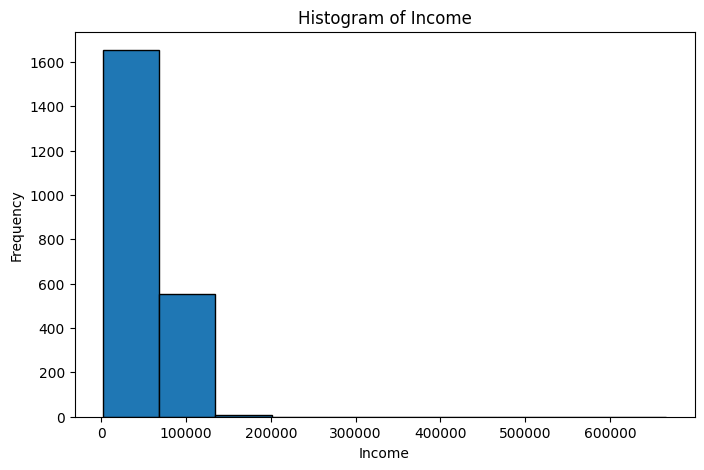

In [45]:
#a10
selected_feature = df['Income'].dropna().values

print("NaNs remaining:", df['Income'].isna().sum())

hist_counts, bin_edges = np.histogram(selected_feature, bins=10)
print("Histogram counts:", hist_counts)
print("Bin edges:", bin_edges)

feature_mean = calculate_mean(selected_feature.reshape(-1, 1))[0]
feature_variance = calculate_variance(selected_feature.reshape(-1, 1))[0]
print("Income mean:", feature_mean)
print("Income variance:", feature_variance)

plt.figure(figsize=(8, 5))
plt.hist(selected_feature, bins=10, edgecolor='black')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Histogram of Income')
plt.show()

In [46]:
#a11

import numpy as np
def kmeans(data, k, iterations):
    centroids = data[:k]
    for _ in range(iterations):
        distance = np.linalg.norm(data[:, None] - centroids, axis=2)
        labels = np.argmin(distance, axis=1)
        new_centroids = np.array([
            data[labels == i].mean(axis=0)
            for i in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

X = df[["Income", "MntWines"]].dropna().to_numpy()
labels, centroids = kmeans(X, 3, 100)
print("Labels")
print(labels)
print("Centroids")
print(centroids)

Labels
[0 0 2 ... 0 2 0]
Centroids
[[5.56852568e+04 3.47049383e+02]
 [2.98794719e+04 3.90107527e+01]
 [8.02561213e+04 6.36768014e+02]]
